# VNExpress News Data Overview

VNExpress là một trong những trang báo điện tử lớn tại Việt Nam. 
Trong project này, nhóm thu thập dữ liệu từ hai chuyên mục:

- Sức khỏe
- Giải trí

Nguồn dữ liệu:

https://vnexpress.net/suc-khoe  
https://vnexpress.net/giai-tri

Mục tiêu của notebook này:

- Hiểu cấu trúc dữ liệu đã crawl
- Phân tích dữ liệu thô (raw data)
- Tìm missing values
- Phát hiện vấn đề cần xử lý trước khi clean data

## 1. Import các thư viện cần thiết

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import os
import re
from collections import Counter

sns.set(style="whitegrid")

pd.set_option('display.max_columns', None)

## 2. Đọc và tìm hiểu dữ liệu

### 2.1 Đọc dữ liệu từ file CSV

In [15]:
df = pd.read_csv("../data/vnexpress_raw_data.csv", encoding="utf-8")

print("Kích thước dataset:", df.shape)

Kích thước dataset: (1184, 11)


### 2.2 Xem vài dòng dữ liệu đầu

In [16]:
df.head()

,title,description,date,category,thumbnail,content,author,tags,group,nums_of_comments,url
0,Không khí lễ hội xuân một thế kỷ trước qua ảnh,Cảnh người dân tham gia lễ hội đền Hai Bà Trưn...,"Thứ sáu, 27/2/2026, 00:00 (GMT+7)","Sân khấu - Mỹ thuật, Mỹ thuật",https://i1-giaitri.vnecdn.net/2026/02/24/den-h...,"Dịp đầu năm, nhiều lễ hội truyền thống được tổ...",Phương Linh,"lễ hội xuân, thế kỷ 20, ảnh xưa",Khác,0,https://vnexpress.net/khong-khi-le-hoi-xuan-mo...
1,Kanye West thừa nhận bị rối loạn tâm thần,Rapper Kanye West cho biết mắc rối loạn lưỡng ...,"Thứ ba, 27/1/2026, 15:04 (GMT+7)","Giới sao, Quốc tế",https://i1-giaitri.vnecdn.net/2026/01/27/kanye...,Trên trang quảng cáo của tờWall Street Journal...,Phương Thảo,"kanye west, rapper kanye west",Khác,0,https://vnexpress.net/kanye-west-thua-nhan-bi-...
2,Katy Perry quấn quýt cựu Thủ tướng Canada,Katy Perry và bạn trai - cựu Thủ tướng Justin ...,"Thứ tư, 11/2/2026, 10:49 (GMT+7)","Giới sao, Quốc tế",https://i1-giaitri.vnecdn.net/2026/02/11/Katy-...,"TrênInstagramngày 10/2, Katy Perry chia sẻ loạ...",Phương Thảo,"katy perry, justin trudeau, cựu thủ tướng cana...",Khác,5,https://vnexpress.net/katy-perry-quan-quyt-cuu...
3,Sỏi to 'bằng nắm tay' trong bàng quang người đ...,"TP HCMÔng Ngọc, 69 tuổi, có sỏi bàng quang 10 ...","Thứ ba, 10/3/2026, 08:00 (GMT+7)","Các bệnh, Tiết niệu - Nam học",https://i1-suckhoe.vnecdn.net/2026/03/09/anh-1...,Ông Ngọc đến Bệnh viện Đa khoa Tâm Anh TP HCM ...,Bảo Anh,"tp hcm, sỏi bàng quang, bệnh tiết niệu",Khác,3,https://vnexpress.net/soi-to-bang-nam-tay-tron...
4,Cuộc đua phim Việt Tết Bính Ngọ,Thị trường phim Việt sôi động với bốn tác phẩm...,"Thứ năm, 12/2/2026, 11:21 (GMT+7)","Phim, Chuyện màn ảnh",https://i1-giaitri.vnecdn.net/2026/01/30/phimt...,"Trước ngày khởi chiếu 17/2 (mùng Một Tết), bốn...",Cát Tiên,"trấn thành, thỏ ơi, nhà ba tôi một phòng, mùi ...",Khác,34,https://vnexpress.net/cuoc-dua-phim-viet-tet-b...


### 2.3 Thông tin các cột dữ liệu

In [17]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1184 entries, 0 to 1183
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   title             1184 non-null   str  
 1   description       1177 non-null   str  
 2   date              1184 non-null   str  
 3   category          1184 non-null   str  
 4   thumbnail         1151 non-null   str  
 5   content           1184 non-null   str  
 6   author            1184 non-null   str  
 7   tags              1177 non-null   str  
 8   group             1184 non-null   str  
 9   nums_of_comments  1184 non-null   int64
 10  url               1184 non-null   str  
dtypes: int64(1), str(10)
memory usage: 101.9 KB


### 2.4 Kiểm tra dữ liệu thiếu

In [18]:
missing_values = df.isnull().sum()

missing_percentage = (missing_values / len(df)) * 100

missing_df = pd.DataFrame({
    "Missing Values": missing_values,
    "Missing (%)": missing_percentage
})

missing_df.sort_values(by="Missing Values", ascending=False)

,Missing Values,Missing (%)
thumbnail,33,2.787162
description,7,0.591216
tags,7,0.591216
title,0,0.000000
date,0,0.000000
category,0,0.000000
content,0,0.000000
author,0,0.000000
group,0,0.000000
nums_of_comments,0,0.000000


### 2.5 Thống kê mô tả

In [19]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
nums_of_comments,1184.0,3.214527,12.137892,0.0,0.0,0.0,2.0,206.0


## 3. Phân bố dữ liệu

### 3.1 Số lượng bài viết theo nhóm

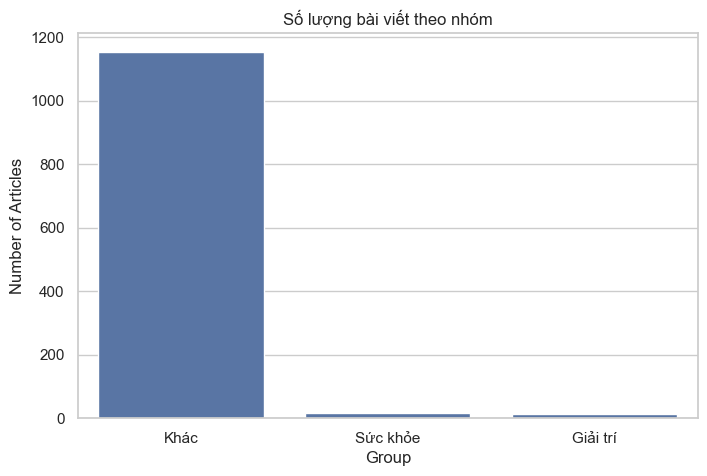

In [20]:
plt.figure(figsize=(8,5))

group_counts = df["group"].value_counts()

sns.barplot(
    x=group_counts.index,
    y=group_counts.values
)

plt.title("Số lượng bài viết theo nhóm")
plt.xlabel("Group")
plt.ylabel("Number of Articles")

plt.show()

### 3.2 Số lượng bài theo category

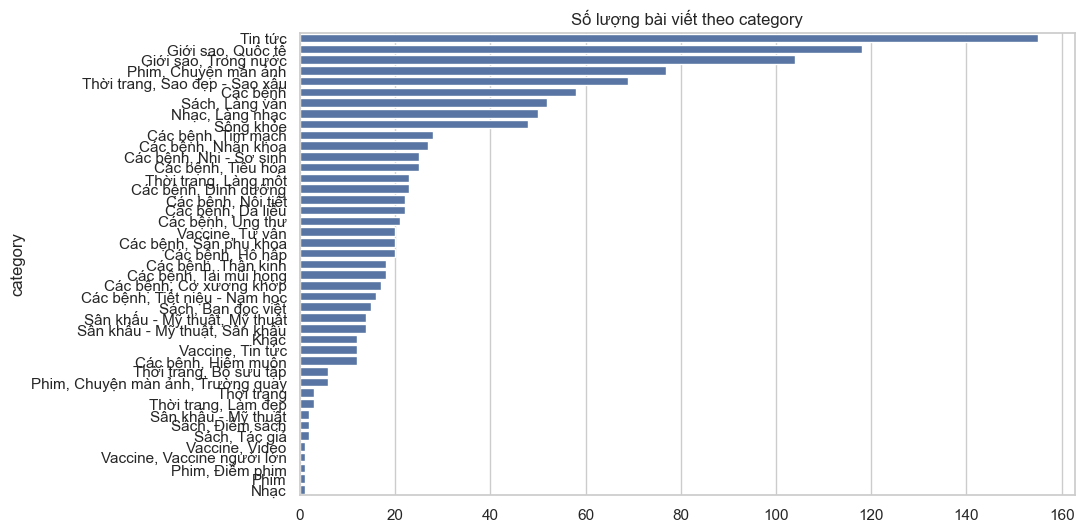

In [21]:
plt.figure(figsize=(10,6))

category_counts = df["category"].value_counts()

sns.barplot(
    y=category_counts.index,
    x=category_counts.values
)

plt.title("Số lượng bài viết theo category")

plt.show()

### 3.3 Phân bố số lượng bình luận

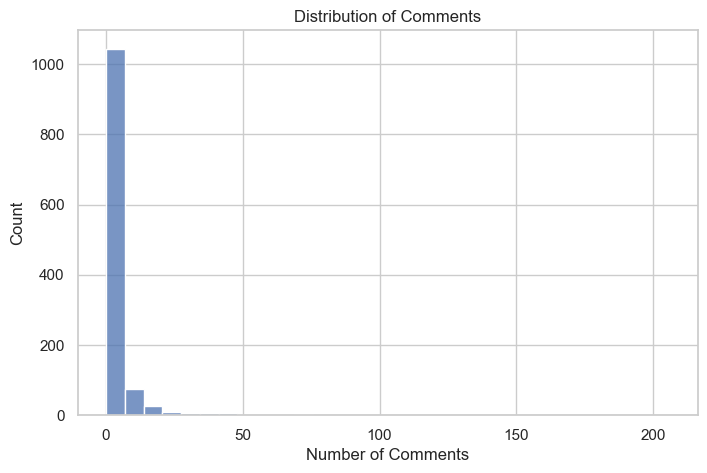

In [22]:
plt.figure(figsize=(8,5))

sns.histplot(df["nums_of_comments"], bins=30)

plt.title("Distribution of Comments")

plt.xlabel("Number of Comments")

plt.show()

### 3.4 Phân tích độ dài title và content

In [23]:
df["title_length"] = df["title"].astype(str).apply(lambda x: len(x.split()))
df["content_length"] = df["content"].astype(str).apply(lambda x: len(x.split()))

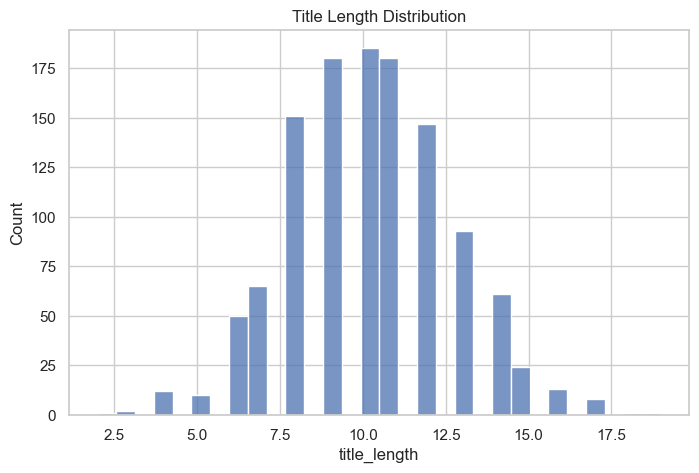

In [24]:
plt.figure(figsize=(8,5))

sns.histplot(df["title_length"], bins=30)

plt.title("Title Length Distribution")

plt.show()

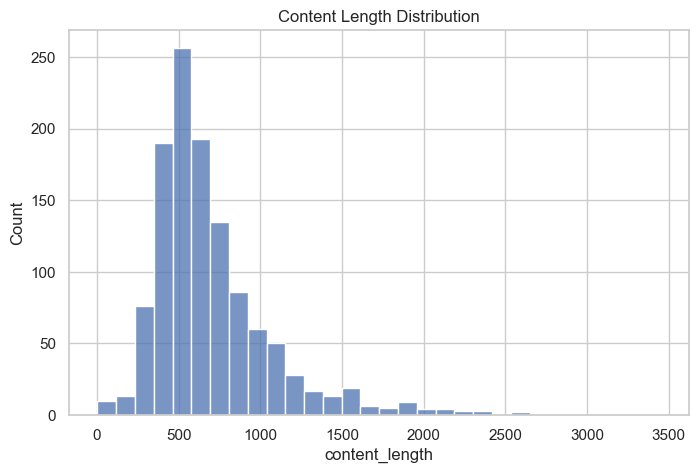

In [25]:
plt.figure(figsize=(8,5))

sns.histplot(df["content_length"], bins=30)

plt.title("Content Length Distribution")

plt.show()

### 3.5 Kiểm tra bài viết bất thường

In [26]:
df.sort_values("content_length", ascending=False).head()

,title,description,date,category,thumbnail,content,author,tags,group,nums_of_comments,url,title_length,content_length
375,Kim Hye Soo - 'Nữ hoàng sexy' Hàn Quốc,"Các chuyên trang sắc đẹp gọi Kim Hye Soo là ""N...","Thứ hai, 2/3/2026, 00:00 (GMT+7)","Thời trang, Sao đẹp - Sao xấu",https://i1-giaitri.vnecdn.net/2026/03/01/Chi-d...,Kim Hye Soo là nhân vật đặc biệt của tạp chíVo...,Như Anh,"kim hye soo, nữ hoàng sexy",Khác,16,https://vnexpress.net/kim-hye-soo-nu-hoang-sex...,9,3454
699,"Dàn sao 'Breaking Bad' ngày ấy, bây giờ",Bryan Cranston và Bob Odenkirk trở thành tên t...,"Thứ ba, 27/1/2026, 12:26 (GMT+7)","Phim, Chuyện màn ảnh",https://i1-giaitri.vnecdn.net/2026/01/26/break...,Trailer seriesBreaking Bad. Video:YouTube Brea...,Quế Chi,"breaking bad, bryan cranston, aaron paul, dean...",Khác,0,https://vnexpress.net/dan-sao-breaking-bad-nga...,8,3194
270,Hai cặp song sinh nhà tài tử Thái gây sốt,"Cặp trai, gái song sinh - con của tài tử Thái ...","Thứ hai, 2/3/2026, 15:59 (GMT+7)","Giới sao, Quốc tế",https://i1-giaitri.vnecdn.net/2026/03/02/Hai-c...,"Hôm 1/3, tài tử Beam Kawee cùng bà xãOil Atipo...",Như Anh,beam kawee,Khác,3,https://vnexpress.net/hai-cap-song-sinh-nha-ta...,10,2576
40,Những cuộc hôn nhân son sắt của Hollywood,"""Biểu tượng nhạc đồng quê"" Dolly Parton có cuộ...","Thứ bảy, 14/2/2026, 11:00 (GMT+7)","Giới sao, Quốc tế",https://i1-giaitri.vnecdn.net/2026/02/13/vo-ch...,Ca sĩDolly Partonvà doanh nhân Carl Dean là mộ...,Phương Thảo,"hollywood, hôn nhân bền bỉ, dolly parton, samu...",Khác,0,https://vnexpress.net/nhung-cuoc-hon-nhan-son-...,8,2546
648,Mối tình 'khắc cốt ghi tâm' của cặp sao Hàn,Jin Tae Hyun ví mối tình của anh với bà xã Par...,"Thứ ba, 24/2/2026, 20:30 (GMT+7)","Giới sao, Quốc tế",https://i1-giaitri.vnecdn.net/2026/02/24/Jin-T...,"Trên trang cá nhân, vợ chồngJin Tae Hyun - Par...",Như Anh,"jin tae hyun, park si eun, hãy nắm tay anh",Khác,3,https://vnexpress.net/moi-tinh-khac-cot-ghi-ta...,10,2412


## 4. Nhận xét về dữ liệu raw

Qua quá trình phân tích dữ liệu thô:

- Dataset gồm các bài viết từ hai chuyên mục:
  - Sức khỏe
  - Giải trí

- Một số vấn đề phát hiện:
  - Có thể tồn tại dữ liệu thiếu
  - Định dạng ngày chưa chuẩn
  - Văn bản chưa được chuẩn hóa
  - Có thể có bài trùng lặp

→ Vì vậy cần bước **data cleaning** để:

- Loại bỏ duplicates
- Chuẩn hóa text
- Chuẩn hóa date
- Xử lý missing values

## 5. Định hướng bài toán

Từ dữ liệu này có thể xây dựng các bài toán:

### Hướng 1: Dự đoán số lượng bình luận
- Input: title_length, content_length, category...
- Output: nums_of_comments

### Hướng 2: Phân loại bài viết
- Phân loại bài viết thuộc nhóm:
  - Sức khỏe
  - Giải trí

### Hướng 3: Phân tích xu hướng nội dung
- Phân tích chủ đề phổ biến
- Phân tích độ dài bài viết